In [5]:
from xml.etree.ElementPath import prepare_child

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from networkx.classes import neighbors

In [6]:
df = pd.read_csv("../data/bank/bank-full.csv" , sep = ';')
df.head()
print(df.shape)
print(df.columns.tolist())

(45211, 17)
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


## 2. Dataset Understanding

The dataset contains information about customers and their interaction
with a bank's direct marketing campaign.

Before performing clustering, we need to understand the meaning and
type of every variable.

In [7]:
print(df.info())
print(df.describe())

for col in df.columns:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(df[col].unique()[:20])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None
                age        balance           day      duration      campaign  \
count  45211.0

## 3. Data Dictionary

| Column      | Meaning                                       | Type        | Role                                  |
| ----------- | --------------------------------------------- | ----------- | ------------------------------------- |
| `age`       | Customer's age                                | Numerical   | Customer characteristic               |
| `job`       | Type of job                                   | Categorical | Customer characteristic               |
| `marital`   | Marital status                                | Categorical | Customer characteristic               |
| `education` | Education level                               | Categorical | Customer characteristic               |
| `default`   | Whether customer has credit in default        | Binary      | Customer characteristic               |
| `balance`   | Average yearly balance                        | Numerical   | Customer characteristic               |
| `housing`   | Whether customer has a housing loan           | Binary      | Customer characteristic               |
| `loan`      | Whether customer has a personal loan          | Binary      | Customer characteristic               |
| `contact`   | Type of communication contact                 | Categorical | Campaign interaction                  |
| `day`       | Last contact day of month                     | Numerical   | Campaign interaction                  |
| `month`     | Last contact month                            | Categorical | Campaign interaction                  |
| `duration`  | Duration of last contact                      | Numerical   | Campaign interaction                  |
| `campaign`  | Number of contacts during current campaign    | Numerical   | Campaign interaction                  |
| `pdays`     | Days since previous campaign contact          | Numerical   | Campaign interaction                  |
| `previous`  | Number of contacts before current campaign    | Numerical   | Campaign interaction                  |
| `poutcome`  | Outcome of previous campaign                  | Categorical | Campaign interaction                  |
| `y`         | Whether customer subscribed to a term deposit | Binary      | **Target — excluded from clustering** |


In [8]:
# Select text/categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Select numerical columns directly
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numeric_cols)


Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## 4. Data Quality Investigation

### 4.1 Missing Values

In [9]:
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_df.sort_values("missing_count", ascending=False)

,missing_count,missing_percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


In [10]:
unknown_counts = {}

for col in df.select_dtypes(include=['object', 'category']):
    unknown_counts[col] = (df[col] == 'unknown').sum()

unknown_df = pd.DataFrame.from_dict(
    unknown_counts,
    orient="index",
    columns=["unknown_count"]
)

unknown_df["unknown_percentage"] = (
        unknown_df["unknown_count"] / len(df) * 100
)

unknown_df = unknown_df.sort_values("unknown_count", ascending=False)


In [11]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{'='*60}")
    print(col)
    print(df[col].value_counts(dropna=False))


job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count

### 4.2 Numerical Feature Distributions

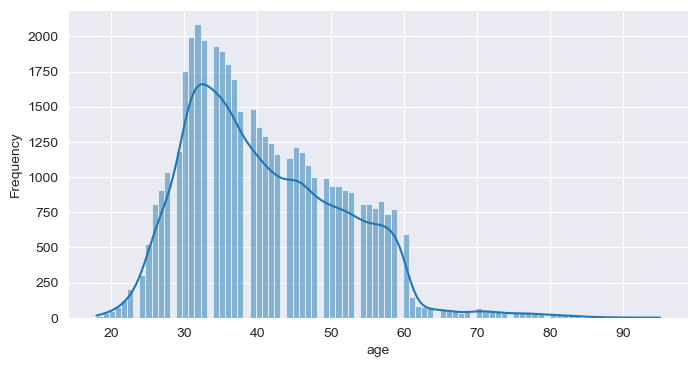

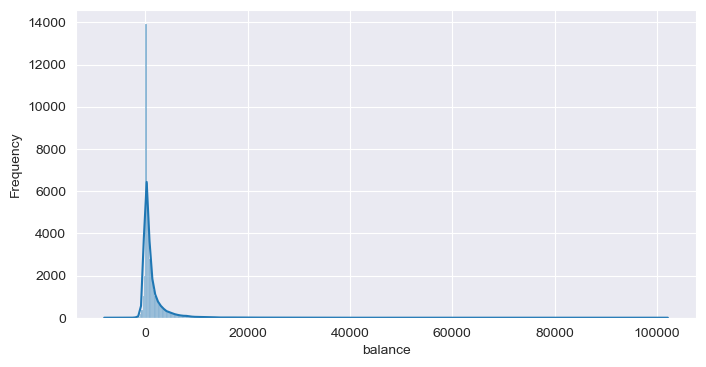

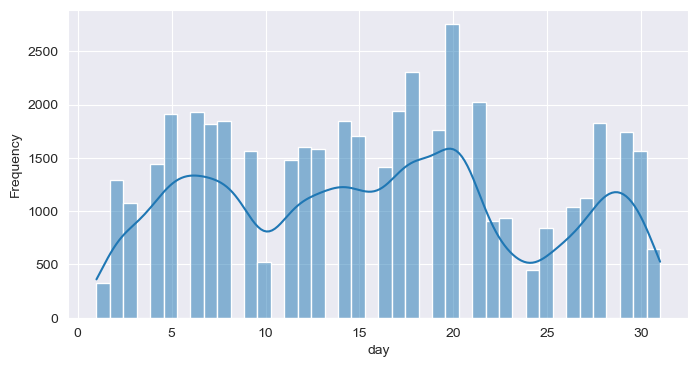

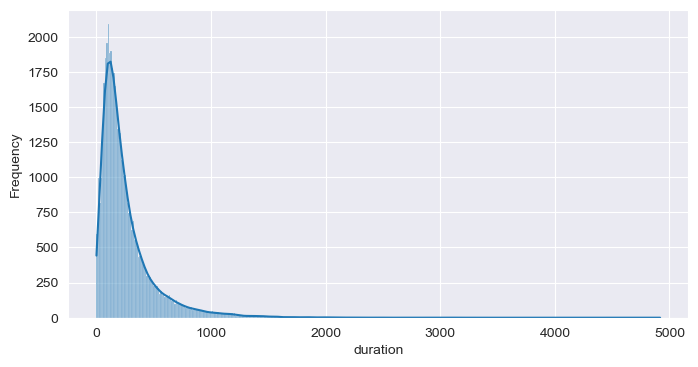

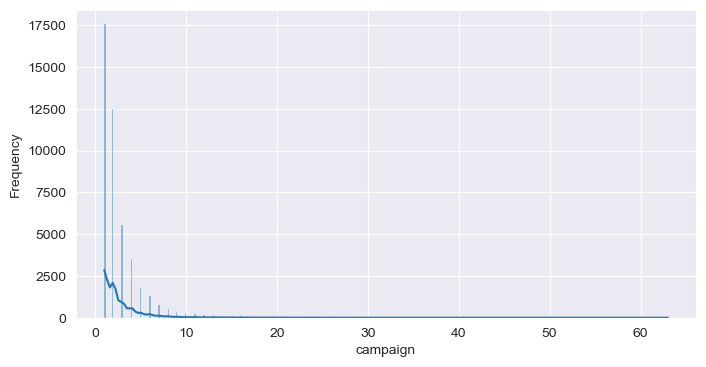

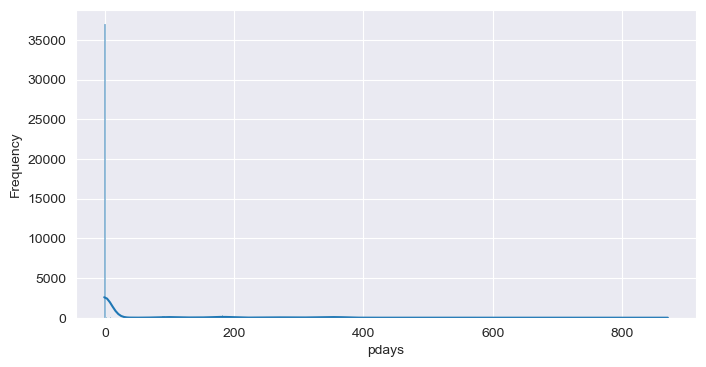

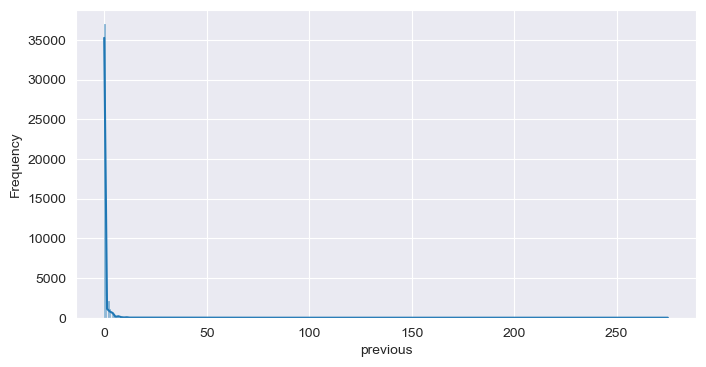

In [12]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col] , kde = True)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [13]:
skewness = df[numeric_cols].skew()

skewness.sort_values(ascending=False)

previous    41.846454
balance      8.360308
campaign     4.898650
duration     3.144318
pdays        2.615715
age          0.684818
day          0.093079
dtype: float64

### Observations

The numerical features show substantially different distributions.

- `previous` is extremely right-skewed, with most observations concentrated near zero.
- `balance` is highly right-skewed because a small number of customers have very large balances.
- `campaign` and `duration` are also strongly right-skewed, indicating long right tails.
- `pdays` is moderately to strongly right-skewed.
- `age` shows moderate right skewness.
- `day` has very low skewness and is approximately symmetric.

These differences are important for clustering because distance-based algorithms
can be affected by feature distributions, scale, and extreme observations.

At this stage, no transformations or outlier removal are performed. These choices
will be investigated later as part of the preprocessing experiments.

### 4.3 Outlier Investigation

We investigate potential outliers in numerical variables using the
Interquartile Range (IQR) rule.

Outliers are identified for investigation only. No observations are
removed at this stage.

In [14]:
outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        "feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percentage": len(outliers) / len(df) * 100
    })

    outlier_df = pd.DataFrame(outlier_summary)

outlier_df = outlier_df.sort_values(
    "outlier_percentage",
    ascending=False
)

outlier_df

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
6,previous,0.0,0.0,0.0,0.0,0.0,8257,18.263255
5,pdays,-1.0,-1.0,0.0,-1.0,-1.0,8257,18.263255
1,balance,72.0,1428.0,1356.0,-1962.0,3462.0,4729,10.459844
3,duration,103.0,319.0,216.0,-221.0,643.0,3235,7.155338
4,campaign,1.0,3.0,2.0,-2.0,6.0,3064,6.777112
0,age,33.0,48.0,15.0,10.5,70.5,487,1.077171
2,day,8.0,21.0,13.0,-11.5,40.5,0,0.000000


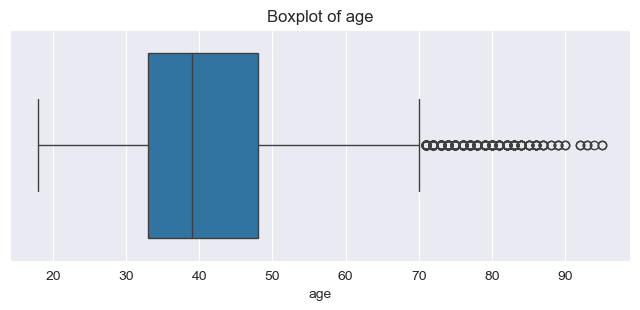

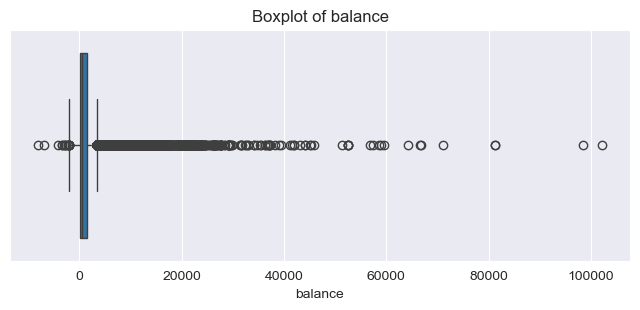

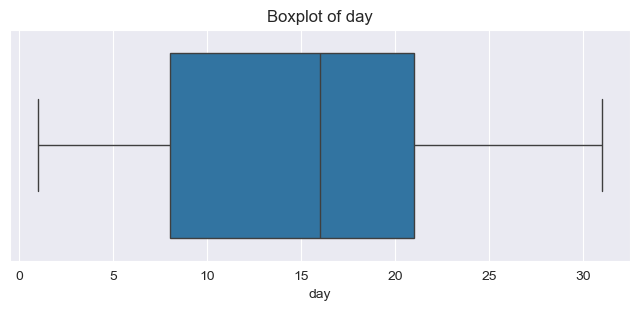

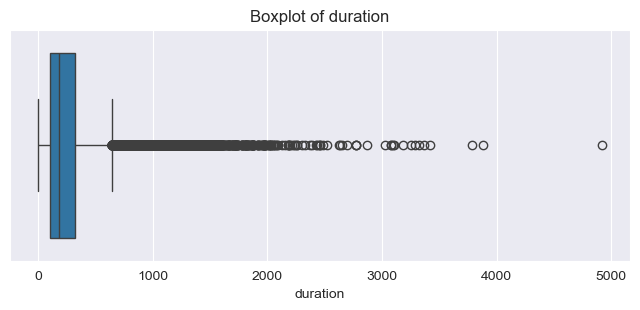

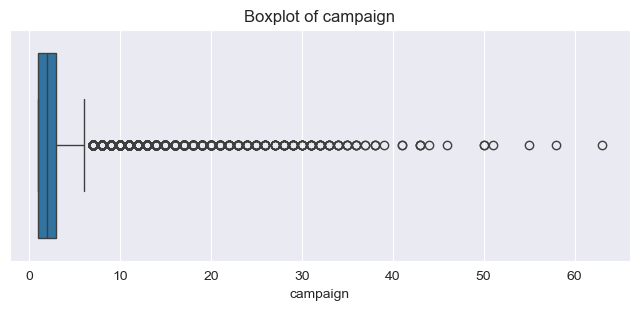

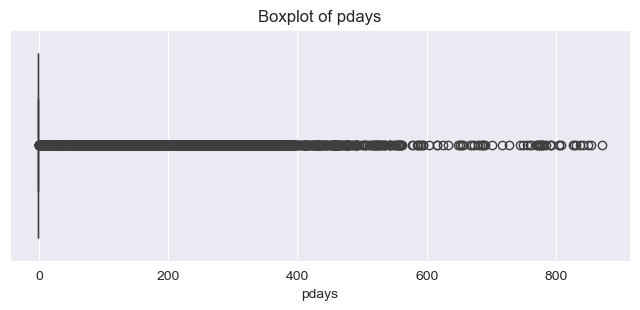

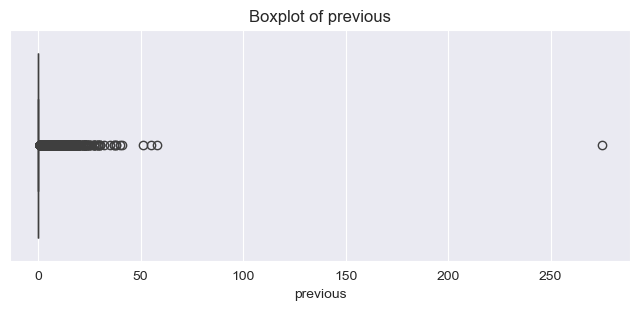

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

### Outlier Investigation Observations

The IQR analysis identifies potential extreme observations in several
numerical features.

`balance`, `duration`, and `campaign` contain a substantial number of
observations beyond the conventional IQR boundaries, consistent with
their right-skewed distributions.

`age` has relatively few IQR-flagged observations, while `day` has none.

For `previous` and `pdays`, the standard IQR rule produces a different
result because the distributions are highly concentrated around a
single value. In both cases, Q1 and Q3 are identical, resulting in an
IQR of zero. Therefore, the observations flagged by the IQR rule should
not automatically be treated as erroneous outliers.

No observations are removed at this stage. The results will instead
inform later preprocessing and representation experiments.

In [16]:
df["pdays"].value_counts().head(10)


pdays
-1      36954
 182      167
 92       147
 183      126
 91       126
 181      117
 370       99
 184       85
 364       77
 95        74
Name: count, dtype: int64

### Interpretation of `pdays` and `previous`

The variables `pdays` and `previous` describe the customer's interaction
with previous marketing campaigns.

`previous` represents the number of contacts performed before the current
campaign. Most customers have a value of zero, indicating no previous
contacts.

`pdays` represents the number of days since the customer was last contacted
in a previous campaign. The value `-1` is a special encoded value indicating
that there was no previous campaign contact. This explains why `pdays` is
highly concentrated at `-1`.

Because these variables contain highly concentrated/special values, the
standard IQR outlier rule is not sufficient to determine whether the
observations are erroneous. The variables will therefore be investigated
further during feature representation and preprocessing.

In [17]:
print(categorical_cols)
categorical_cols = [col for col in categorical_cols if col != "y"]
print(categorical_cols)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### 4.4 Categorical Feature Distributions

In [18]:
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(df[col].value_counts())


job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
no     44396
yes      815
Name: count, dtype: int64

housing
yes    25130
no     20081
Name: count, dtype: int64

loan
no     37967
yes     7244
Name: count, dtype: int64

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

poutcome
unknown    36959
failure     490

In [19]:
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(col)
    print(
        df[col]
        .value_counts(normalize=True)  # Pandas converts the count proportions
        .mul(100)
        .round(2)
    )


job
job
blue-collar      21.53
management       20.92
technician       16.80
admin.           11.44
services          9.19
retired           5.01
self-employed     3.49
entrepreneur      3.29
unemployed        2.88
housemaid         2.74
student           2.07
unknown           0.64
Name: proportion, dtype: float64

marital
marital
married     60.19
single      28.29
divorced    11.52
Name: proportion, dtype: float64

education
education
secondary    51.32
tertiary     29.42
primary      15.15
unknown       4.11
Name: proportion, dtype: float64

default
default
no     98.2
yes     1.8
Name: proportion, dtype: float64

housing
housing
yes    55.58
no     44.42
Name: proportion, dtype: float64

loan
loan
no     83.98
yes    16.02
Name: proportion, dtype: float64

contact
contact
cellular     64.77
unknown      28.80
telephone     6.43
Name: proportion, dtype: float64

month
month
may    30.45
jul    15.25
aug    13.82
jun    11.81
nov     8.78
apr     6.49
feb     5.86
jan     3.10
oct 

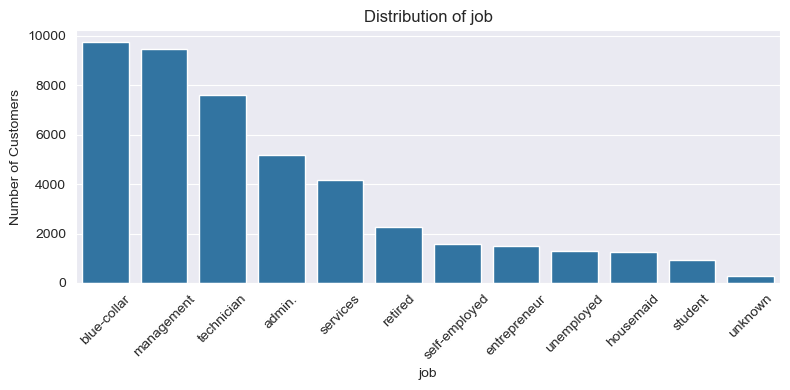

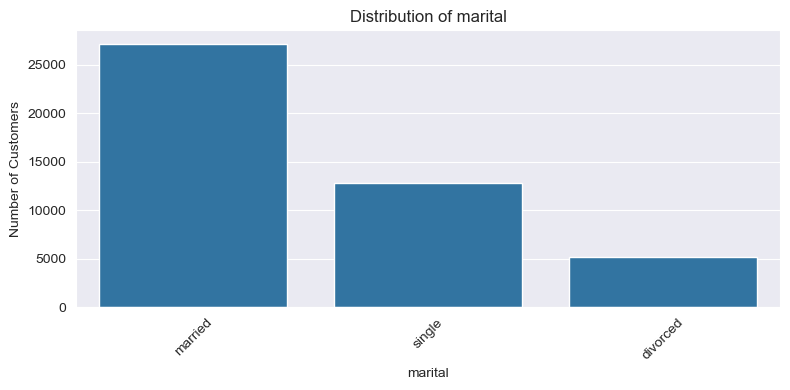

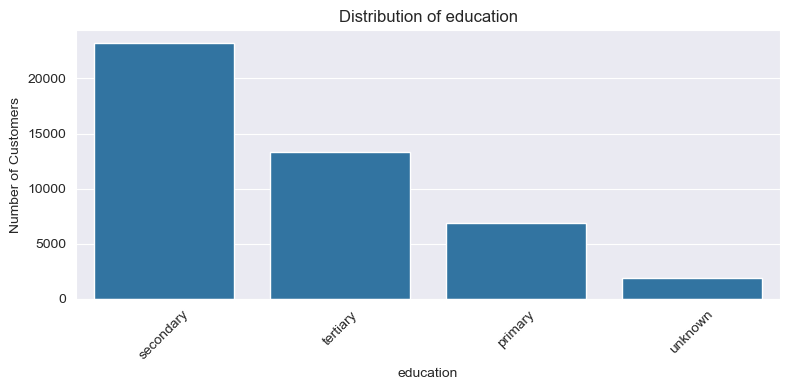

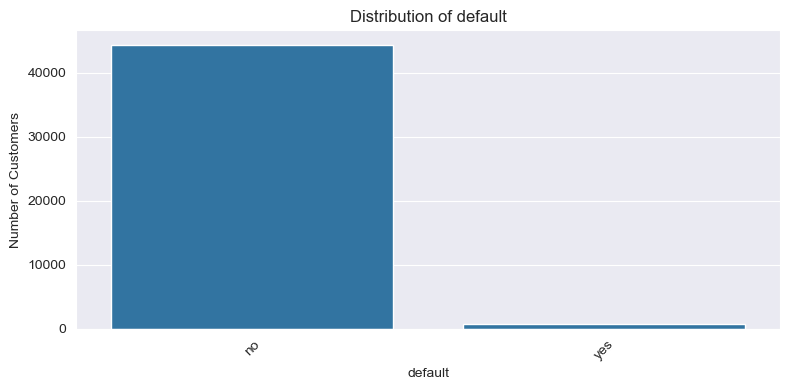

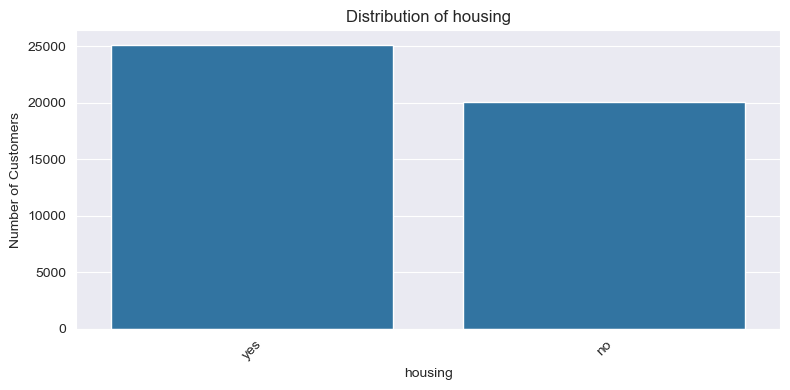

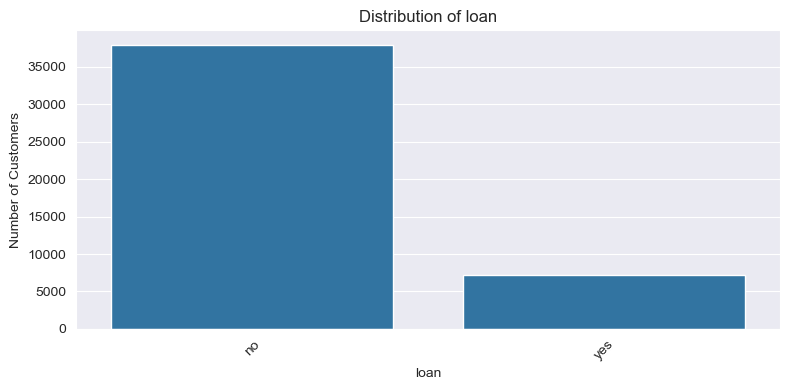

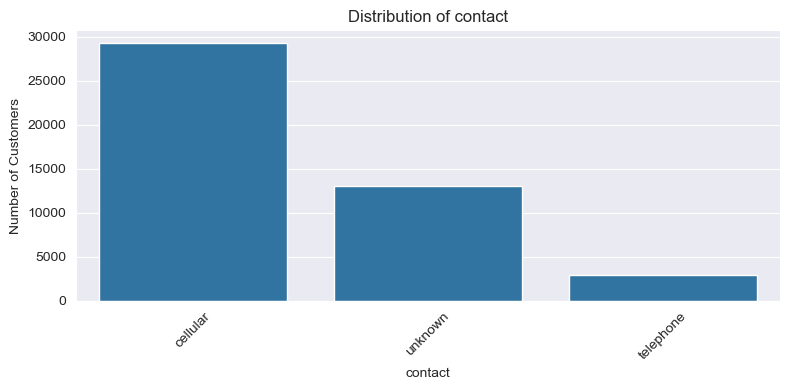

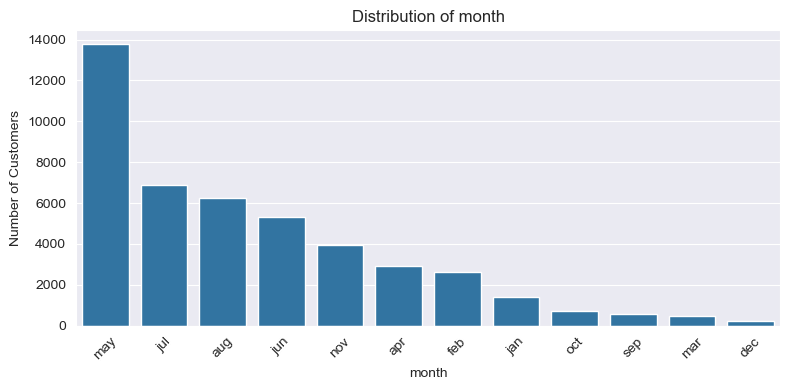

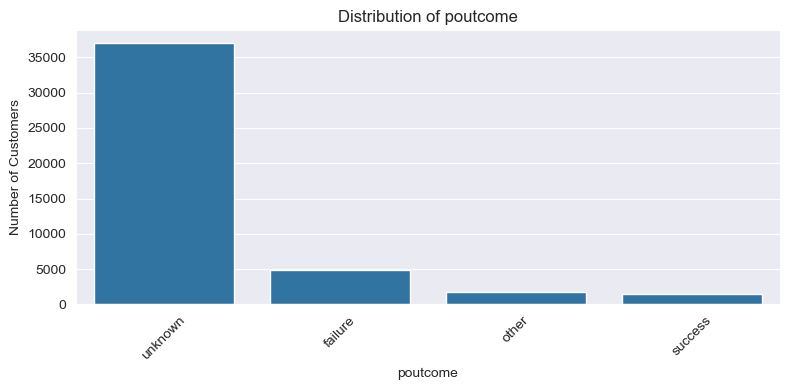

In [20]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    order =  df[col].value_counts().index

    sns.countplot(
        data = df,
        x = col,
        order=order
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [21]:
categorical_summary = []

for col in categorical_cols:
    counts = df[col].value_counts()

    categorical_summary.append({
        "feature": col,
        "unique_categories": df[col].nunique(),
        "most_common_category": counts.index[0],
        "most_common_count": counts.iloc[0],
        "most_common_percentage": counts.iloc[0] / len(df) * 100
    })

categorical_summary_df = pd.DataFrame(categorical_summary)

categorical_summary_df

,feature,unique_categories,most_common_category,most_common_count,most_common_percentage
0,job,12,blue-collar,9732,21.525735
1,marital,3,married,27214,60.193316
2,education,4,secondary,23202,51.319369
3,default,2,no,44396,98.197341
4,housing,2,yes,25130,55.583818
5,loan,2,no,37967,83.977351
6,contact,3,cellular,29285,64.774059
7,month,12,may,13766,30.448342
8,poutcome,4,unknown,36959,81.747805


### 4.5 Correlation Analysis

Correlation analysis is used to investigate relationships between
numerical variables and identify potentially redundant information.

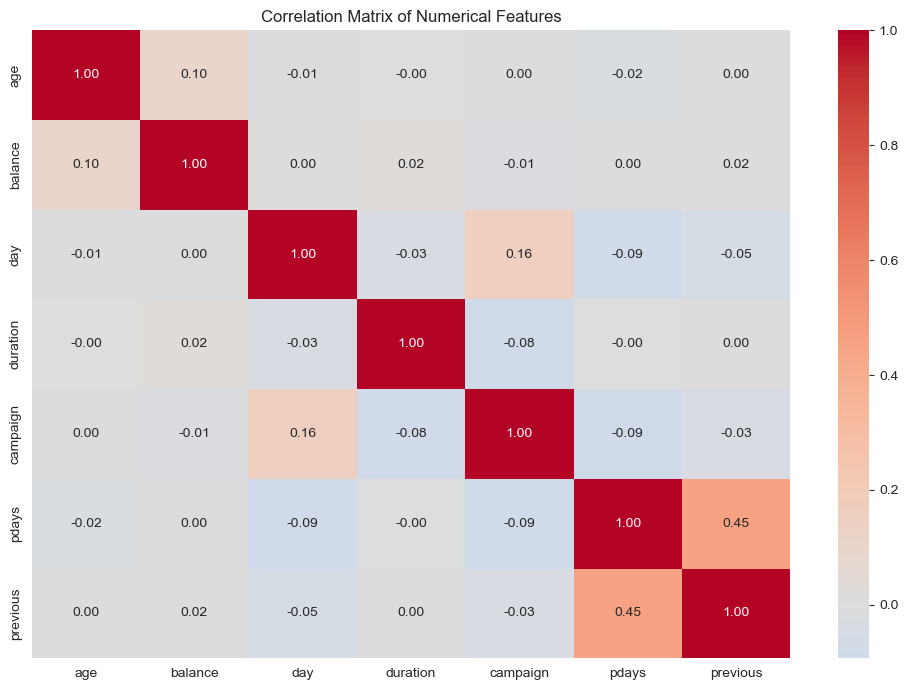

In [22]:
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [23]:
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(key=abs, ascending=False)
)

corr_pairs.head(10)

pdays     previous    0.454820
day       campaign    0.162490
age       balance     0.097783
day       pdays      -0.093044
campaign  pdays      -0.088628
duration  campaign   -0.084570
day       previous   -0.051710
campaign  previous   -0.032855
day       duration   -0.030206
age       pdays      -0.023758
dtype: float64

### Correlation Observations

The numerical features generally show weak linear relationships with one
another. The strongest relationship is between `pdays` and `previous`
(correlation ≈ 0.455), which is expected because both variables describe
previous campaign activity.

The relationship between `day` and `campaign` is weak (≈ 0.162), while
the remaining feature pairs show correlations close to zero.

Therefore, there is no strong evidence of severe numerical redundancy
based on pairwise linear correlation alone. No numerical features are
removed based solely on correlation at this stage.

Correlation analysis is treated as one part of EDA rather than as the
sole basis for feature selection.

## 5. Clustering Objective

### Primary Objective

The primary objective is to discover naturally occurring customer
segments based primarily on customer characteristics and financial
attributes.

The clustering process will not use the original target variable `y`.

### Representation Experiment

Because the dataset also contains marketing campaign interaction
variables, we will investigate how including these variables changes
the resulting segmentation.

Therefore, we will compare different feature representations rather
than assuming that all available variables should automatically be
used for clustering.

In [24]:
customer_features = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan"
]

campaign_features = [
    "contact",
    "day",
    "month",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "poutcome"
]

target = "y"

In [25]:
print("Customer features:")
print(customer_features)

print("\nCampaign features:")
print(campaign_features)

print("\nTarget:")
print(target)

Customer features:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']

Campaign features:
['contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

Target:
y


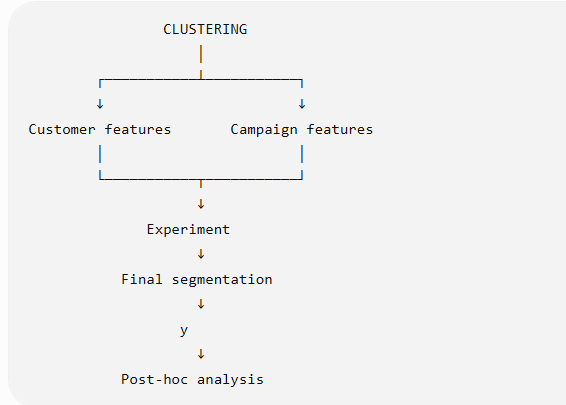

In [26]:
print("Customer features:")
for col in customer_features:
    print("-", col)

print("\nCampaign features:")
for col in campaign_features:
    print("-", col)

print("\nTarget:")
print("-", target)

Customer features:
- age
- job
- marital
- education
- default
- balance
- housing
- loan

Campaign features:
- contact
- day
- month
- duration
- campaign
- pdays
- previous
- poutcome

Target:
- y


## 6. Preprocessing and Representation

The clustering data is constructed using customer characteristics only.
The target variable `y` is excluded from the clustering representation.

In [27]:
X_customer = df[customer_features].copy()
print(X_customer.shape)
X_customer.head()

(45211, 8)


,age,job,marital,education,default,balance,housing,loan
0,58,management,married,tertiary,no,2143,yes,no
1,44,technician,single,secondary,no,29,yes,no
2,33,entrepreneur,married,secondary,no,2,yes,yes
3,47,blue-collar,married,unknown,no,1506,yes,no
4,33,unknown,single,unknown,no,1,no,no


In [28]:
customer_numeric = [
    "age",
    "balance"
]

customer_categorical = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan"
]

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(

    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore" , sparse_output=False),
            customer_categorical
        ),
        (
            "numerical",
            StandardScaler(),
            customer_numeric
        )
        ],
            remainder = "passthrough" # only when to skip one type like we only enocde category adn want to skip numerical
)

In [30]:
X_customer_processed = preprocessor.fit_transform(X_customer)
feature_names = preprocessor.get_feature_names_out()

print(X_customer_processed.shape)
print(feature_names)
print(X_customer_processed[:5])

(45211, 27)
['categorical__job_admin.' 'categorical__job_blue-collar'
 'categorical__job_entrepreneur' 'categorical__job_housemaid'
 'categorical__job_management' 'categorical__job_retired'
 'categorical__job_self-employed' 'categorical__job_services'
 'categorical__job_student' 'categorical__job_technician'
 'categorical__job_unemployed' 'categorical__job_unknown'
 'categorical__marital_divorced' 'categorical__marital_married'
 'categorical__marital_single' 'categorical__education_primary'
 'categorical__education_secondary' 'categorical__education_tertiary'
 'categorical__education_unknown' 'categorical__default_no'
 'categorical__default_yes' 'categorical__housing_no'
 'categorical__housing_yes' 'categorical__loan_no' 'categorical__loan_yes'
 'numerical__age' 'numerical__balance']
[[ 0.          0.          0.          0.          1.          0.
   0.          0.          0.          0.          0.          0.
   0.          1.          0.          0.          0.          1.
   0.  

In [31]:
print("Missing values:",
      np.isnan(X_customer_processed).sum())

print("Mean of age:",
      X_customer_processed[:, -2].mean())

print("Mean of balance:",
      X_customer_processed[:, -1].mean())

print("Std of age:",
      X_customer_processed[:, -2].std())

print("Std of balance:",
      X_customer_processed[:, -1].std())

Missing values: 0
Mean of age: 2.112250197654497e-16
Mean of balance: 1.5087501411817835e-17
Std of age: 1.0
Std of balance: 1.0


In [32]:
print("Shape:", X_customer_processed.shape)

print("\nMinimum value:", X_customer_processed.min())
print("Maximum value:", X_customer_processed.max())

Shape: (45211, 27)

Minimum value: -3.0811485466035458
Maximum value: 33.09477575528038


Original skewness: 8.360308326166326
Transformed skewness: -1.5834610936153366


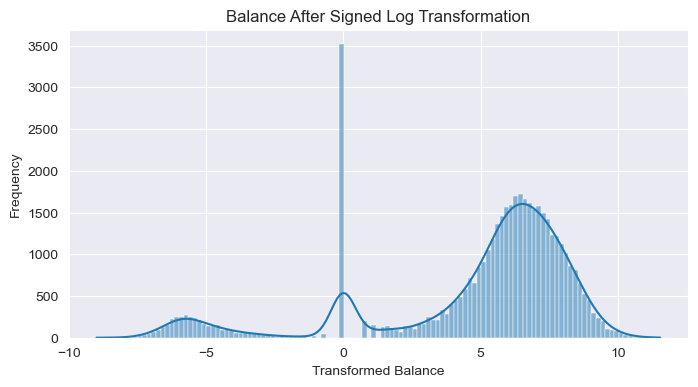

In [33]:
balance_transformed = np.sign(df["balance"]) * np.log1p(
    np.abs(df["balance"])
)

print("Original skewness:",
      df["balance"].skew())

print("Transformed skewness:",
      balance_transformed.skew())

plt.figure(figsize=(8, 4))
sns.histplot(balance_transformed, kde=True)
plt.xlabel("Transformed Balance")
plt.ylabel("Frequency")
plt.title("Balance After Signed Log Transformation")
plt.show()

In [34]:
balance_shifted = df["balance"] - df["balance"].min() + 1
balance_log = np.log1p(balance_shifted)

print("Original skewness:", df["balance"].skew())
print("Signed-log skewness:", balance_transformed.skew())
print("Shifted-log skewness:", balance_log.skew())

Original skewness: 8.360308326166326
Signed-log skewness: -1.5834610936153366
Shifted-log skewness: 1.4669168081279749


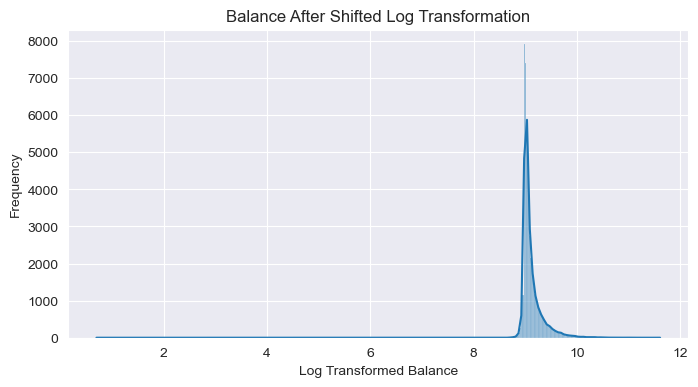

In [35]:
plt.figure(figsize=(8, 4))
sns.histplot(balance_log, kde=True)
plt.xlabel("Log Transformed Balance")
plt.ylabel("Frequency")
plt.title("Balance After Shifted Log Transformation")
plt.show()

In [36]:
X_customer_transformed = df[customer_features].copy()

balance_shifted = (
        X_customer_transformed["balance"]
        - X_customer_transformed["balance"].min()
        + 1
)

X_customer_transformed["balance"] = np.log1p(balance_shifted)


preprocessor_transformed = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            customer_categorical
        ),
        (
            "numerical",
            StandardScaler(),
            customer_numeric
        )
    ]
)

X_customer_processed_transformed = (
    preprocessor_transformed.fit_transform(
        X_customer_transformed
    )
)

feature_names_transformed = (
    preprocessor_transformed.get_feature_names_out()
)

print("Shape:", X_customer_processed_transformed.shape)

print(
    "Missing values:",
    np.isnan(X_customer_processed_transformed).sum()
)

Shape: (45211, 27)
Missing values: 0


In [37]:
for feature in feature_names:
    if "unknown" in feature:
        print(feature)

categorical__job_unknown
categorical__education_unknown


**X_customer_processed | balance → StandardScaler**
**X_customer_processed_transformed | balance → shifted log → StandardScaler**

## **1. K-Means Clustering**

In [38]:
from sklearn.cluster import KMeans

In [39]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_customer_processed)
cluster_labels

array([2, 0, 0, ..., 2, 2, 0], shape=(45211,), dtype=int32)

In [40]:
print(cluster_labels[:20])
print("Number of customers:", len(cluster_labels))

cluster_counts = (
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)

print("Cluster counts:")
print(cluster_counts)

print("\nCluster percentages:")
print(cluster_counts / len(cluster_labels) * 100)

print("\nInertia:")
print(kmeans.inertia_)

[2 0 0 2 0 0 0 0 2 0 0 0 2 2 2 2 0 2 2 0]
Number of customers: 45211
Cluster counts:
0    26651
1     1391
2    17169
Name: count, dtype: int64

Cluster percentages:
0    58.948044
1     3.076685
2    37.975272
Name: count, dtype: float64

Inertia:
160265.7863339051


`The imbalance:`

`58.95% | 3.08% | 37.98%`

`makes me want to inspect the actual cluster characteristics.`

In [41]:
df_customer_clusters = df[customer_features].copy()

df_customer_clusters["cluster"] = cluster_labels
cluster_numeric_summary = (
    df_customer_clusters
    .groupby("cluster")[customer_numeric]
    .mean()
)

print(cluster_numeric_summary)

               age       balance
cluster                         
0        33.829762    862.271397
1        43.390367  13691.818835
2        51.768536   1139.493680


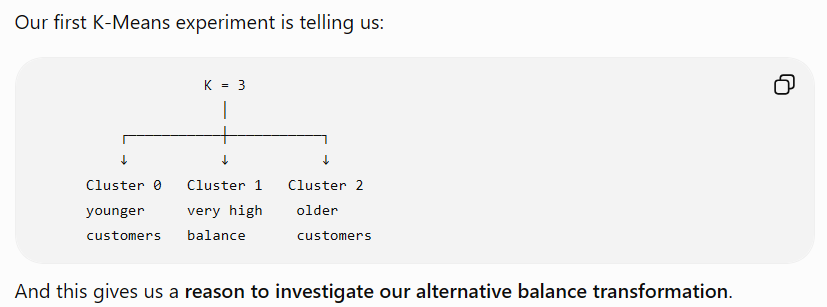

In [42]:
job_distribution = pd.crosstab(
    df_customer_clusters["cluster"],
    df_customer_clusters["job"],
    normalize="index"
) * 100

print(job_distribution.round(2))

job      admin.  blue-collar  entrepreneur  housemaid  management  retired  \
cluster                                                                      
0         12.90        22.14          2.93       1.52       21.23     0.17   
1          8.05        13.80          4.10       2.73       33.07     5.90   
2          9.45        21.20          3.78       4.65       19.45    12.45   

job      self-employed  services  student  technician  unemployed  unknown  
cluster                                                                     
0                 3.47     10.57     3.40       18.65        2.72     0.31  
1                 5.61      5.03     1.65       15.38        3.88     0.79  
2                 3.35      7.39     0.05       14.05        3.05     1.13  


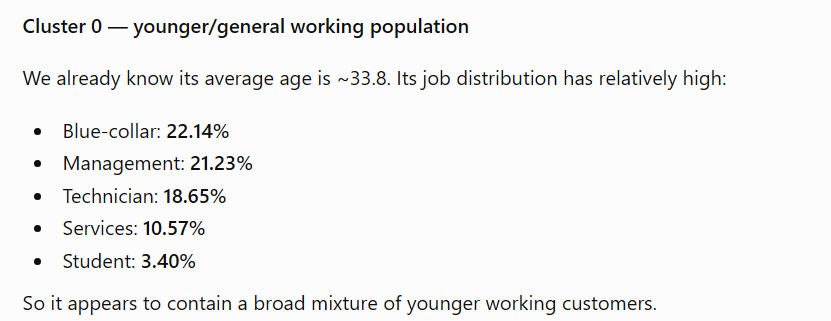
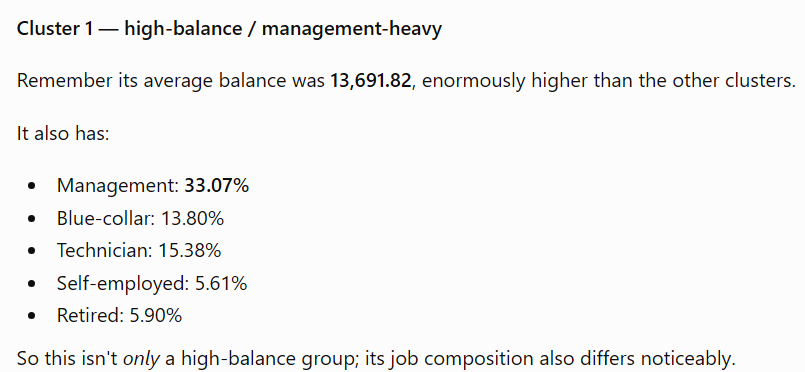
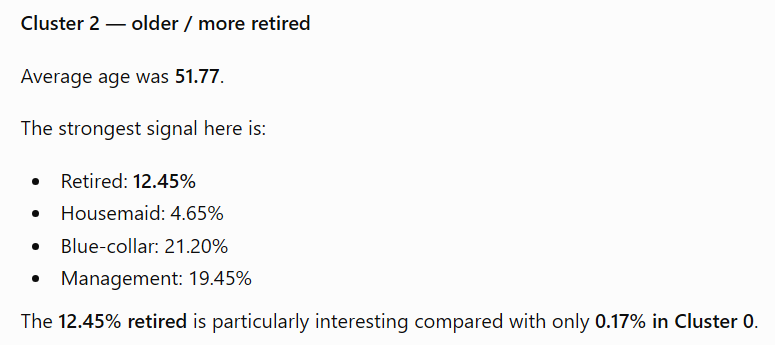

**`Cluster 1 is strongly distinguished by very high account balances and has a relatively high proportion of management customers, while Cluster 2 is older and contains a substantially higher proportion of retired customers.`**

In [43]:
marital_distribution = pd.crosstab(
    df_customer_clusters["cluster"],
    df_customer_clusters["marital"],
    normalize="index"
) * 100

print(marital_distribution.round(2))


education_distribution = pd.crosstab(
    df_customer_clusters["cluster"],
    df_customer_clusters["education"],
    normalize="index"
) * 100

print(education_distribution.round(2))

marital  divorced  married  single
cluster                           
0            8.39    48.83   42.78
1            8.55    65.56   25.88
2           16.62    77.40    5.99
education  primary  secondary  tertiary  unknown
cluster                                         
0             9.47      55.49     32.05     2.99
1            12.44      36.88     46.01     4.67
2            24.19      46.02     24.00     5.79


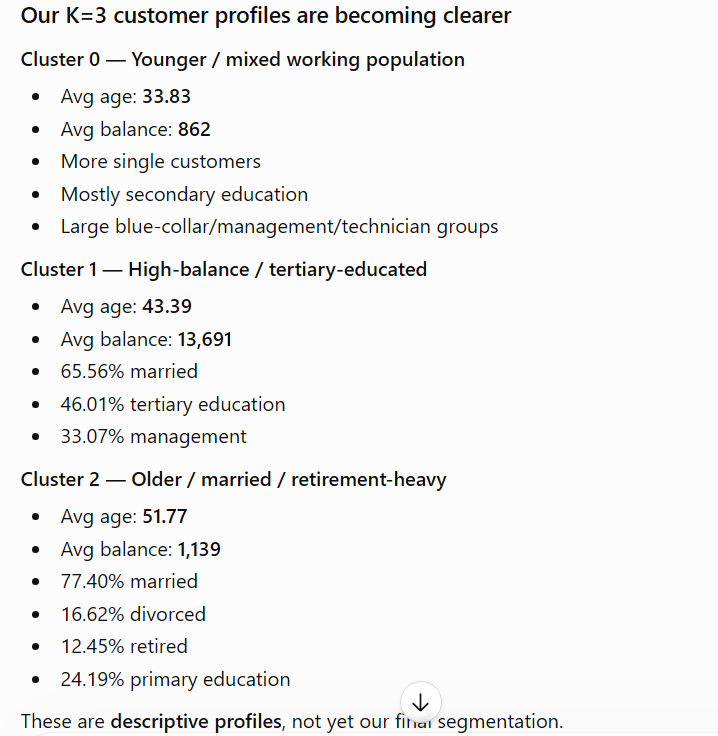

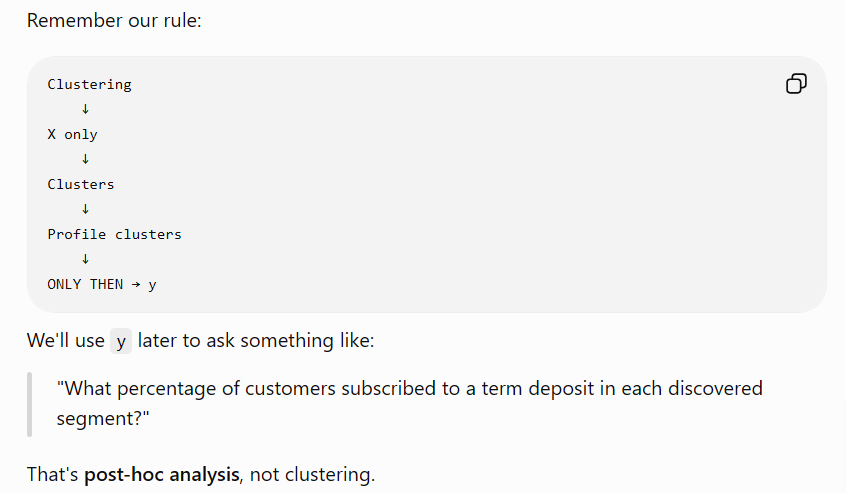

In [44]:
for col in ["default", "housing", "loan"]:
    distribution = pd.crosstab(
        df_customer_clusters["cluster"],
        df_customer_clusters[col],
        normalize="index"
    ) * 100

    print(f"\n{'='*50}")
    print(col)
    print(distribution.round(2))


default
default     no   yes
cluster             
0        98.06  1.94
1        99.93  0.07
2        98.26  1.74

housing
housing     no    yes
cluster              
0        35.20  64.80
1        55.79  44.21
2        57.81  42.19

loan
loan        no    yes
cluster              
0        83.86  16.14
1        94.75   5.25
2        83.28  16.72


| Characteristic | Cluster 0                  | Cluster 1            | Cluster 2        |
| -------------- | -------------------------- | -------------------- | ---------------- |
| Size           | **58.95%**                 | **3.08%**            | **37.98%**       |
| Age            | Younger                    | Middle               | **Older**        |
| Balance        | Normal                     | **Extremely high**   | Normal           |
| Marital        | More single                | More married         | **Most married** |
| Education      | Mostly secondary           | **Most tertiary**    | More primary     |
| Job            | Mixed working              | **Management-heavy** | **More retired** |
| Housing        | **Most have housing loan** | Less                 | Less             |
| Personal loan  | ~16%                       | **5.25%**            | ~17%             |
| Default        | Similar                    | Very low             | Similar          |


`We used the balance with StandardScaler() for the Kmeans with K = 3
And we got Cluster 1 with only 3.08 percent, and it is imbalanced and this is beacue the cluster is isolated as it has customer with high balance so we will now use the dataframe in which we log shifted the balance`

In [45]:
kmeans_transformed = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=42
)

cluster_labels_transformed = kmeans_transformed.fit_predict(X_customer_processed_transformed)

cluster_counts_transformed = (
    pd.Series(cluster_labels_transformed)
    .value_counts()
    .sort_index()
)

print("Cluster counts:")
print(cluster_counts_transformed)

print("\nCluster percentages:")
print(
    (cluster_counts_transformed / len(cluster_labels_transformed) * 100)
    .round(2)
)

print("\nInertia:")
print(kmeans_transformed.inertia_)

Cluster counts:
0    25228
1     4004
2    15979
Name: count, dtype: int64

Cluster percentages:
0    55.80
1     8.86
2    35.34
Name: count, dtype: float64

Inertia:
158177.17440423951


In [46]:
from sklearn.metrics import silhouette_score

# Baseline kmeans with balance just StandScaler
silhouette_baseline = silhouette_score(
    X_customer_processed,
    cluster_labels
)

print("Baseline Silhouette Score:",
      silhouette_baseline)

# Transformed kmeans with balance with log shifted and StandScaler
silhouette_transformed = silhouette_score(
    X_customer_processed_transformed,
    cluster_labels_transformed
)

print("Transformed Silhouette Score:",
      silhouette_transformed)

Baseline Silhouette Score: 0.17617289401754083
Transformed Silhouette Score: 0.17281669129649327


## **Using Elbow Method the best n_cluster for Kmeans**

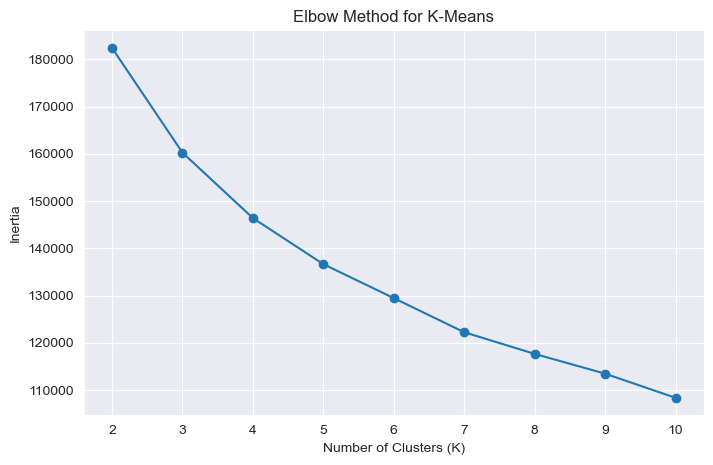

In [47]:
# Baseline

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_customer_processed)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.xticks(k_values)
plt.grid(True)

plt.show()

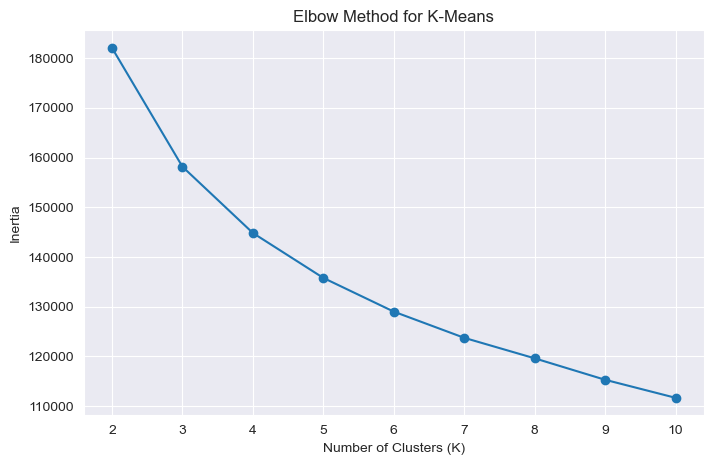

In [48]:
# Transformed

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_customer_processed_transformed)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [49]:
from sklearn.metrics import silhouette_score

for k in [4, 5]:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_customer_processed)

    score = silhouette_score(
        X_customer_processed,
        labels
    )

    print(f"K={k}, Silhouette={score:.4f}")

K=4, Silhouette=0.1500
K=5, Silhouette=0.1428


### Why did we choose **K = 3** instead of K = 4 or K = 5?

The main reason is **Silhouette Score**.

|     K | Silhouette Score | Interpretation           |
| ----: | ---------------: | ------------------------ |
| **3** |       **0.1762** | Best among tested values |
|     4 |           0.1500 | Lower                    |
|     5 |           0.1428 | Lower                    |

The **Elbow Method** did not show a very sharp elbow. It suggested that **K=4–5 could be candidates**, but it did not clearly establish one exact K.

Therefore, we used the Silhouette Score to make the final decision.

### Simple reasoning

* **K=3:** 0.1762 ✅
* **K=4:** 0.1500 ❌
* **K=5:** 0.1428 ❌

As K increases from 3 → 4 → 5, the silhouette score **gets worse**, meaning the clusters become less well separated relative to their internal cohesion.

So:

> **We selected K=3 because it gave the highest Silhouette Score among the candidate K values, while the Elbow Method did not provide a strong enough reason to prefer K=4 or K=5.**

## Visualize the K-Means clusters

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_customer_pca = pca.fit_transform(X_customer_processed)

print("Original dimensions:", X_customer_processed.shape)
print("PCA dimensions:", X_customer_pca.shape)

print("Explained variance ratio:",
      pca.explained_variance_ratio_)

print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

Original dimensions: (45211, 27)
PCA dimensions: (45211, 2)
Explained variance ratio: [0.24716959 0.1977566 ]
Total explained variance: 0.444926189194203


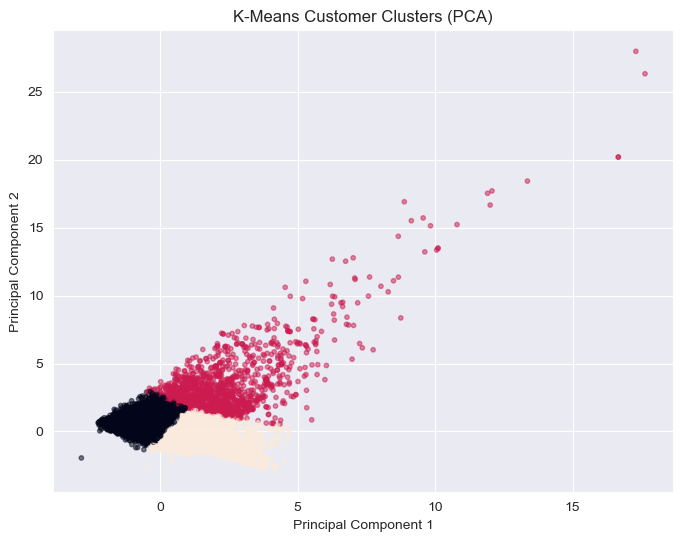

In [51]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_customer_pca[:, 0],
    X_customer_pca[:, 1],
    c=cluster_labels,
    s=10,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Customer Clusters (PCA)")
plt.show()

# 9. Hierarchical Clustering

In [52]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import train_test_split

In [57]:
X_agglo, _ = train_test_split(
    X_customer_processed,
    train_size=10000,
    random_state=42
)

print("Sample shape:", X_agglo.shape)

Sample shape: (10000, 27)


In [58]:
agglo = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)
agglo_labels = agglo.fit_predict(X_agglo)

In [59]:
pd.Series(agglo_labels).value_counts().sort_index()

0    6423
1     822
2    2755
Name: count, dtype: int64

In [60]:
agglo_silhouette = silhouette_score(
    X_agglo,
    agglo_labels
)

print("Agglomerative Silhouette Score:", agglo_silhouette)

Agglomerative Silhouette Score: 0.11869820484100456


### Observation

Agglomerative Clustering with 3 clusters achieved a Silhouette Score of 0.1187.
This is lower than the K-Means Silhouette Score of 0.1762. Therefore, K-Means
shows better cluster separation for the customer-characteristics representation
in this experiment.

# 10. DBSCAN

In [66]:
from sklearn.cluster import DBSCAN

X_dbscan, _ = train_test_split(
    X_customer_processed,
    train_size=10000,
    random_state=42
)

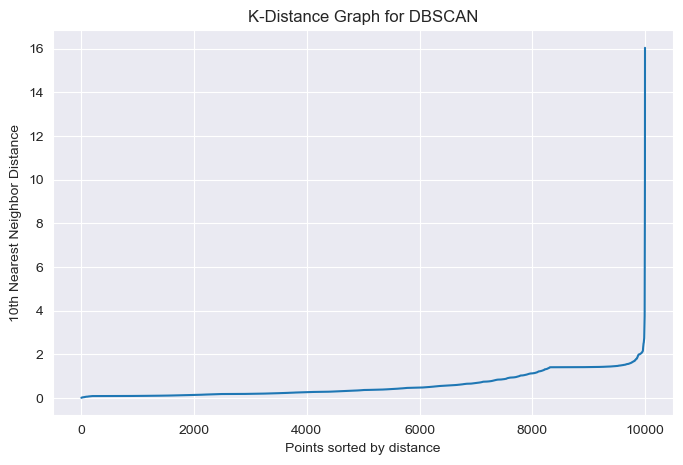

In [67]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_dbscan)

distances , indices = neighbors.kneighbors(X_dbscan)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("10th Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN")
plt.show()

`The elbow is around distance 1.5 - 2.0 so taking the eps  = 1.5`

In [78]:
for eps in [0.6, 0.8, 1.0, 1.2 , 1.3 , 1.4]:

    db = DBSCAN(
        eps=eps,
        min_samples=1
    )

    labels = db.fit_predict(X_dbscan)

    counts = pd.Series(labels).value_counts()

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = (labels == -1).sum()

    print(f"\neps = {eps}")
    print("Clusters:", n_clusters)
    print("Noise points:", noise)
    print(counts.sort_index().head(10))


eps = 0.6
Clusters: 111
Noise points: 2602
-1    2602
 0     168
 1     418
 2      70
 3      15
 4     164
 5     135
 6      75
 7     330
 8     491
Name: count, dtype: int64

eps = 0.8
Clusters: 127
Noise points: 1978
-1    1978
 0     170
 1     247
 2      23
 3     423
 4      72
 5      18
 6     164
 7     138
 8      76
Name: count, dtype: int64

eps = 1.0
Clusters: 138
Noise points: 1622
-1    1622
 0     173
 1     247
 2      23
 3     433
 4     494
 5      75
 6      19
 7     164
 8     140
Name: count, dtype: int64

eps = 1.2
Clusters: 146
Noise points: 1395
-1    1395
 0     173
 1     250
 2      23
 3     436
 4     495
 5      77
 6      20
 7     164
 8     141
Name: count, dtype: int64

eps = 1.3
Clusters: 148
Noise points: 1337
-1    1337
 0     173
 1     251
 2      23
 3     438
 4     495
 5      77
 6      20
 7     164
 8     143
Name: count, dtype: int64

eps = 1.4
Clusters: 150
Noise points: 1290
-1    1290
 0     176
 1     251
 2      23
 3     438
 

### Observation

DBSCAN was highly sensitive to the choice of `eps` for the customer-characteristics
representation. Smaller values produced a large number of small clusters and a
substantial number of noise points, while increasing `eps` to 1.5 caused almost
all observations to merge into a single cluster. Therefore, DBSCAN did not produce
a meaningful customer segmentation for this representation.

# 11. Spectral Clustering

In [80]:
X_spectral, _ = train_test_split(
    X_customer_processed,
    train_size=3000,
    random_state=42
)

print("Sample shape:", X_spectral.shape)

Sample shape: (3000, 27)


In [89]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=3,
    affinity="rbf",
    gamma = 2,
    random_state=42
)

spectral_labels = spectral.fit_predict(X_spectral)
pd.Series(spectral_labels).value_counts().sort_index()

0    2985
1      13
2       2
Name: count, dtype: int64

In [84]:
spectral_n = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42
)

spectral_n_labels = spectral_n.fit_predict(X_spectral)
pd.Series(spectral_n_labels).value_counts().sort_index()

0     777
1    1746
2     477
Name: count, dtype: int64

* **RBF:** 2985, 13, 2 → highly imbalanced clusters.
* Changing **γ = 1 to 2** did not improve the result.
* **Nearest Neighbors:** 777, 1746, 477 → more balanced distribution.
* It captures **local neighborhood relationships** better.
* Therefore, **Nearest Neighbors is preferred for this dataset.**


In [90]:
from sklearn.metrics import silhouette_score

spectral_silhouette = silhouette_score(
    X_spectral,
    spectral_n_labels
)

print("Spectral Clustering Silhouette Score:", spectral_silhouette)

Spectral Clustering Silhouette Score: 0.04468291818818561


### Observation

Spectral Clustering using nearest-neighbor affinity achieved a Silhouette Score
of 0.0447. This is lower than both K-Means (0.1762) and Agglomerative Clustering
(0.1187), indicating weaker cluster separation for the customer-characteristics
representation. Although the cluster sizes were more balanced, the low
Silhouette Score suggests that the resulting groups overlap considerably.

# 12. Gaussian Mixture Model (GMM)

### Calculating the BIC and AIC score for determining the value of K.

In [91]:
from sklearn.mixture import GaussianMixture

components = range(2, 11)

bic_scores = []
aic_scores = []

for k in components:
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_customer_processed)

    bic_scores.append(gmm.bic(X_customer_processed))
    aic_scores.append(gmm.aic(X_customer_processed))

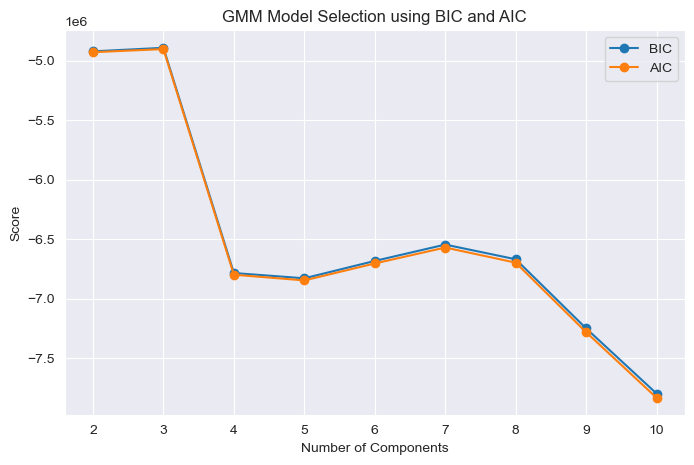

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(components, bic_scores, marker="o", label="BIC")
plt.plot(components, aic_scores, marker="o", label="AIC")

plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("GMM Model Selection using BIC and AIC")
plt.legend()
plt.show()

`Lower BIC/AIC = better model fit`

`So K = 10`

In [93]:
gmm_final = GaussianMixture(
    n_components=10,
    random_state=42
)

gmm_labels = gmm_final.fit_predict(X_customer_processed)

In [94]:
pd.Series(gmm_labels).value_counts().sort_index()

0    10849
1     3946
2     5050
3     2671
4     2076
5     6819
6     1571
7     7003
8     2518
9     2708
Name: count, dtype: int64

In [95]:
from sklearn.metrics import silhouette_score

gmm_silhouette = silhouette_score(
    X_customer_processed,
    gmm_labels
)

print("GMM Silhouette Score:", gmm_silhouette)

GMM Silhouette Score: 0.07122869182316946


### GMM Evaluation

The final GMM with 10 components achieved a Silhouette Score of 0.0712. This
was lower than K-Means (0.1762) and Agglomerative Clustering (0.1187), indicating
weaker separation according to the Silhouette metric.

However, the number of GMM components was selected using BIC and AIC, which
evaluate probabilistic model fit rather than directly maximizing cluster
separation. Therefore, the GMM result should be interpreted using both its
model-selection criteria and clustering quality metrics.

# 13. Campaign Interaction / History Representation

In [96]:
campaign_features = [
    "contact",
    "day",
    "month",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "poutcome"
]

X_campaign = df[campaign_features].copy()

print("Shape:", X_campaign.shape)

Shape: (45211, 8)


In [97]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import  OneHotEncoder, StandardScaler

campaign_categorical = [
    "contact",
    "month",
    "poutcome"
]

campaign_numeric = [
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

campaign_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            campaign_categorical
        ),
        (
            "numerical",
            StandardScaler(),
            campaign_numeric
        )
    ]
)

X_campaign_processed = campaign_preprocessor.fit_transform(X_campaign)

campaign_feature_names = (
    campaign_preprocessor.get_feature_names_out()
)

print("Processed shape:", X_campaign_processed.shape)
print("Missing values:", pd.isna(X_campaign_processed).sum())

Processed shape: (45211, 24)
Missing values: 0


### Choosing K using Elbow Method

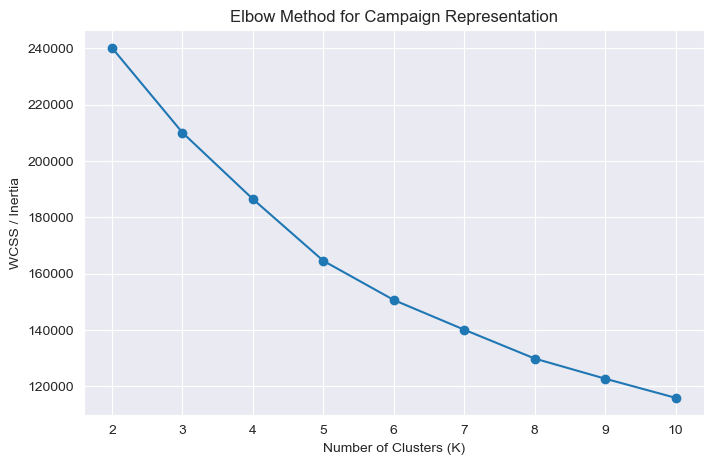

In [100]:
inertias_campaign = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_campaign_processed)
    inertias_campaign.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias_campaign, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for Campaign Representation")
plt.show()

### Selecting K using Silhouette Score

In [101]:
from sklearn.metrics import silhouette_score

silhouette_campaign = []

for k in [3, 4, 5]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_campaign_processed)

    score = silhouette_score(
        X_campaign_processed,
        labels
    )

    silhouette_campaign.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 3, Silhouette Score = 0.1865
K = 4, Silhouette Score = 0.1969
K = 5, Silhouette Score = 0.2103


### Selecting the Final K

The Elbow Method suggested a possible elbow around K=4–5. Silhouette Scores
were then calculated for K=3, K=4, and K=5. K=5 achieved the highest
Silhouette Score of 0.2103, compared with 0.1969 for K=4 and 0.1865 for K=3.

Therefore, K=5 was selected as the preferred number of clusters for the
campaign interaction representation.

In [103]:
kmeans_campaign_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

campaign_labels_final = kmeans_campaign_final.fit_predict(
    X_campaign_processed
)
pd.Series(campaign_labels_final).value_counts().sort_index()

0    16382
1    16926
2     1390
3     7111
4     3402
Name: count, dtype: int64

In [105]:
df_campaign_clusters = df[campaign_features].copy()
df_campaign_clusters["cluster"] = campaign_labels_final

df_campaign_clusters.groupby("cluster")[
    campaign_numeric
].mean().round(2)

,day,duration,campaign,pdays,previous
cluster,,,,,
0,8.55,205.44,2.22,1.12,0.05
1,23.02,192.45,2.57,0.97,0.04
2,21.95,142.87,15.82,-0.49,0.02
3,14.13,237.51,2.09,245.31,3.39
4,15.88,929.26,2.43,11.44,0.18


### Campaign Categorical Profiling

In [106]:
for col in campaign_categorical:
    print(f"\n--- {col} ---")
    print(
        pd.crosstab(
            df_campaign_clusters["cluster"],
            df_campaign_clusters[col],
            normalize="index"
        ).round(3) * 100
    )


--- contact ---
contact  cellular  telephone  unknown
cluster                              
0            54.8        5.7     39.5
1            63.5        6.7     29.8
2            56.2        9.6     34.2
3            91.8        7.3      0.9
4            66.1        5.3     28.6

--- month ---
month     apr   aug  dec   feb  jan   jul   jun  mar   may   nov  oct  sep
cluster                                                                   
0         2.7  15.4  0.4   9.4  0.3  12.5  18.3  1.0  36.7   1.0  0.9  1.3
1         7.2  14.7  0.2   0.9  5.0  21.0   8.9  0.8  24.9  14.4  1.5  0.5
2         0.7  31.9  0.0   1.5  0.1  29.1  19.6  0.6  16.0   0.4  0.0  0.0
3        13.9   5.4  1.5  11.1  5.8   3.1   2.6  2.1  32.9  14.4  3.9  3.3
4         7.8  12.0  0.5   4.3  2.5  19.4  11.2  0.6  28.7  10.2  1.5  1.3

--- poutcome ---
poutcome  failure  other  success  unknown
cluster                                   
0             0.8    0.8      1.3     97.1
1             0.9    0.6      

### Observation

The campaign-based clusters show clear differences in previous campaign history.
Cluster 3 is distinct because all observations have a known `poutcome`, with
63.3% classified as failure, 21.6% as other, and 15.1% as success. In contrast,
the remaining clusters are dominated by `poutcome = unknown`, ranging from
92.3% to 99.6%.

The clusters also differ in contact method and campaign month distributions.
Overall, the segmentation appears to capture differences in campaign
interaction and previous campaign history.

## 15. Campaign Cluster Visualization

In [107]:
from sklearn.decomposition import PCA

pca_campaign = PCA(n_components=2, random_state=42)

X_campaign_pca = pca_campaign.fit_transform(
    X_campaign_processed
)

print("Original dimensions:", X_campaign_processed.shape)
print("PCA dimensions:", X_campaign_pca.shape)
print("Explained variance ratio:", pca_campaign.explained_variance_ratio_)
print(
    "Total explained variance:",
    pca_campaign.explained_variance_ratio_.sum()
)

Original dimensions: (45211, 24)
PCA dimensions: (45211, 2)
Explained variance ratio: [0.25447418 0.17613818]
Total explained variance: 0.43061235817444676


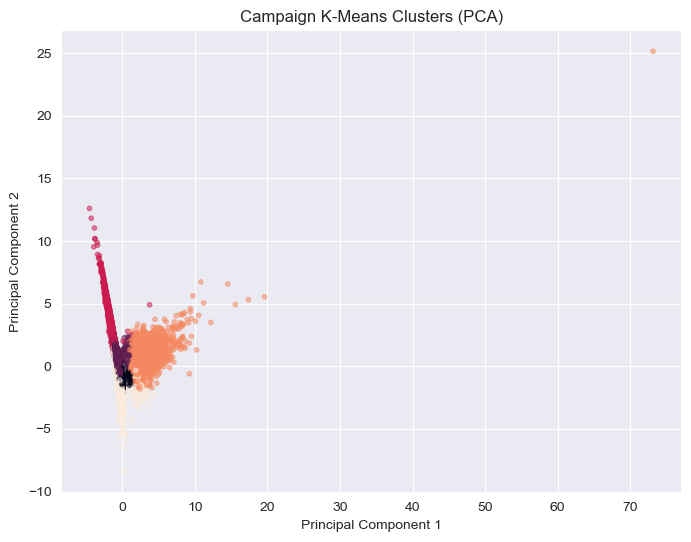

In [108]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_campaign_pca[:, 0],
    X_campaign_pca[:, 1],
    c=campaign_labels_final,
    s=10,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Campaign K-Means Clusters (PCA)")
plt.show()

###  Observation

The PCA visualization of the campaign-based K-Means clusters shows some
structure, but substantial overlap remains between the clusters. This is
consistent with the Silhouette Score of 0.2103, indicating moderate but not
strong cluster separation. The clustering was performed in the full processed
feature space, while PCA was used only for two-dimensional visualization.

In [111]:
# ============================================
# Campaign Representation - Algorithm Comparison
# ============================================

from sklearn.cluster import AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

# --------------------------------------------
# 1. Samples for computationally expensive models
# --------------------------------------------

# Agglomerative: 10,000 samples
X_campaign_agglo, _ = train_test_split(
    X_campaign_processed,
    train_size=10000,
    random_state=42
)

# DBSCAN: 10,000 samples
X_campaign_dbscan, _ = train_test_split(
    X_campaign_processed,
    train_size=10000,
    random_state=42
)

# Spectral: 3,000 samples
X_campaign_spectral, _ = train_test_split(
    X_campaign_processed,
    train_size=3000,
    random_state=42
)


# ============================================
# 2. Agglomerative Clustering
# ============================================

agglo_campaign = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

agglo_campaign_labels = agglo_campaign.fit_predict(
    X_campaign_agglo
)

agglo_score = silhouette_score(
    X_campaign_agglo,
    agglo_campaign_labels
)


# ============================================
# 3. DBSCAN
# ============================================

dbscan_campaign = DBSCAN(
    eps=1.0,
    min_samples=10
)

dbscan_campaign_labels = dbscan_campaign.fit_predict(
    X_campaign_dbscan
)

# Remove noise (-1) before calculating silhouette
dbscan_mask = dbscan_campaign_labels != -1

if (
        dbscan_mask.sum() > 1
        and len(set(dbscan_campaign_labels[dbscan_mask])) > 1
):
    dbscan_score = silhouette_score(
        X_campaign_dbscan[dbscan_mask],
        dbscan_campaign_labels[dbscan_mask]
    )
else:
    dbscan_score = None


# ============================================
# 4. Spectral Clustering
# ============================================

spectral_campaign = SpectralClustering(
    n_clusters=5,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42
)

spectral_campaign_labels = spectral_campaign.fit_predict(
    X_campaign_spectral
)

spectral_score = silhouette_score(
    X_campaign_spectral,
    spectral_campaign_labels
)


# ============================================
# 5. GMM
# ============================================

gmm_campaign = GaussianMixture(
    n_components=5,
    random_state=42
)

gmm_campaign_labels = gmm_campaign.fit_predict(
    X_campaign_processed
)

gmm_score = silhouette_score(
    X_campaign_processed,
    gmm_campaign_labels
)


# ============================================
# Final Campaign Algorithm Comparison
# ============================================

campaign_algorithm_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Agglomerative",
        "DBSCAN",
        "Spectral",
        "GMM"
    ],
    "Silhouette Score": [
        0.2103,       # Campaign K-Means K=5
        agglo_score,
        dbscan_score,
        spectral_score,
        gmm_score
    ]
})

campaign_algorithm_comparison.sort_values(
    "Silhouette Score",
    ascending=False
)

,Algorithm,Silhouette Score
0,K-Means,0.210300
2,DBSCAN,0.163208
1,Agglomerative,0.157401
4,GMM,0.095735
3,Spectral,0.042063


## 16. Comparison of Clustering Results

The comparison shows that K-Means achieved the highest Silhouette Score of 0.2103 for the campaign interaction representation. DBSCAN and Agglomerative Clustering achieved lower scores of 0.1632 and 0.1574 respectively, while GMM achieved 0.0957. Spectral Clustering produced the lowest score of 0.0421.

Therefore, K-Means provided the best cluster separation among the tested algorithms for the campaign-based representation.

# 17. t-SNE Visualization

## Customer Characteristics

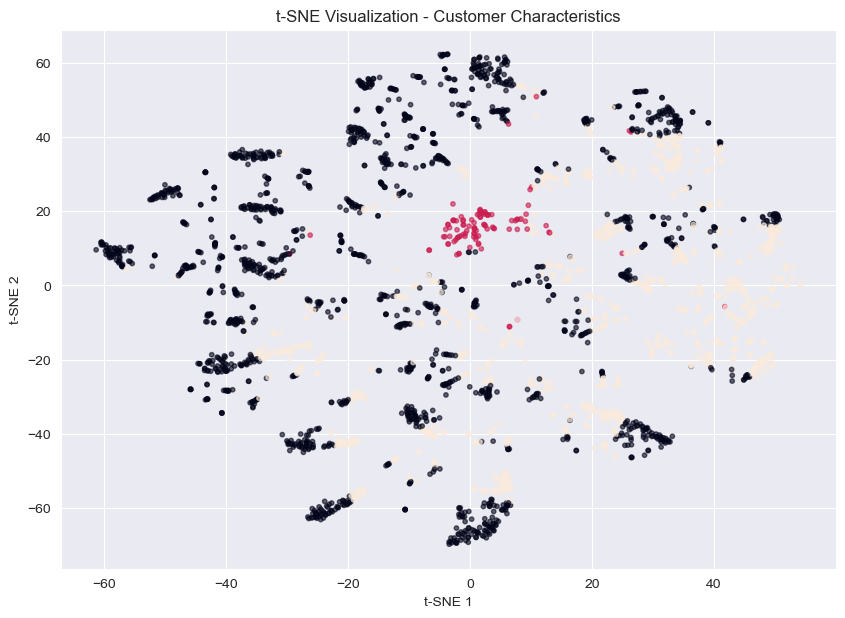

In [112]:
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Take a 3,000-customer sample
X_tsne_customer, _, y_tsne_customer, _ = train_test_split(
    X_customer_processed,
    cluster_labels,
    train_size=3000,
    random_state=42
)

# Apply t-SNE
tsne_customer = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_customer_tsne = tsne_customer.fit_transform(X_tsne_customer)

# Plot
plt.figure(figsize=(10, 7))

plt.scatter(
    X_customer_tsne[:, 0],
    X_customer_tsne[:, 1],
    c=y_tsne_customer,
    s=10,
    alpha=0.6
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization - Customer Characteristics")
plt.show()

### Observation

The t-SNE visualization of the customer-characteristics representation shows some local grouping, but substantial overlap remains between the K-Means clusters. The clusters are distributed across several regions of the t-SNE space rather than forming three clearly separated groups.

This observation is consistent with the Silhouette Score of 0.1762, which indicates that the customer segments have relatively weak separation. Therefore, the K-Means clusters capture some customer-level structure, but the segments are not strongly distinct.

## Campaign t-SNE

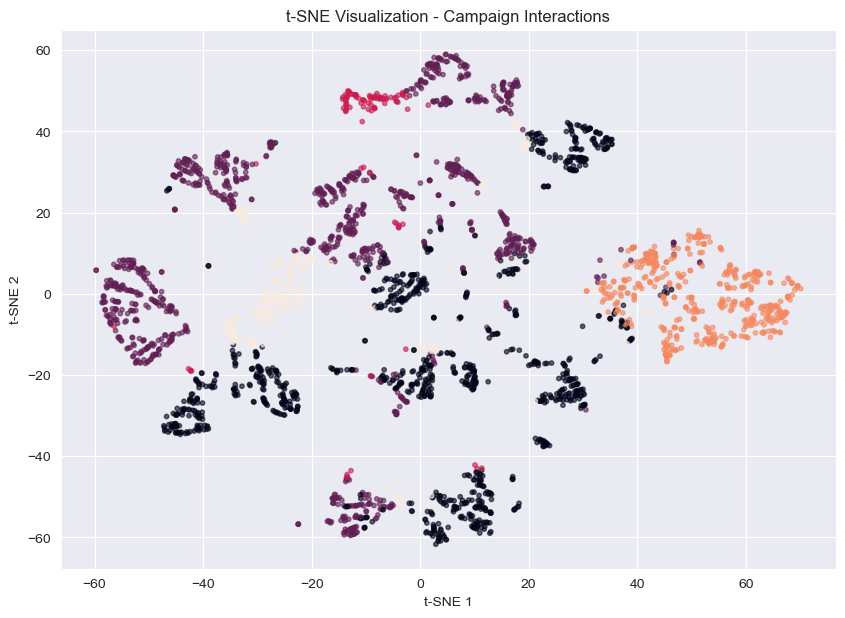

In [113]:
# Take a 3,000-customer sample
X_tsne_campaign, _, y_tsne_campaign, _ = train_test_split(
    X_campaign_processed,
    campaign_labels_final,
    train_size=3000,
    random_state=42
)

# Apply t-SNE
tsne_campaign = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_campaign_tsne = tsne_campaign.fit_transform(X_tsne_campaign)

# Plot
plt.figure(figsize=(10, 7))

plt.scatter(
    X_campaign_tsne[:, 0],
    X_campaign_tsne[:, 1],
    c=y_tsne_campaign,
    s=10,
    alpha=0.6
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization - Campaign Interactions")
plt.show()

### Observation

The t-SNE visualization of the campaign interaction representation shows more visible local grouping compared with the customer-characteristics representation. Several compact groups can be observed, although some overlap between clusters remains.

One cluster forms a particularly noticeable concentration on the right side of the visualization, while other clusters are distributed across multiple regions. Overall, the campaign-based representation shows stronger visual structure than the customer-characteristics representation.

This is consistent with the higher Silhouette Score of 0.2103 for the campaign representation compared with 0.1762 for the customer-characteristics representation.

# 18. UMAP Visualization

## Customer Characteristics

C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


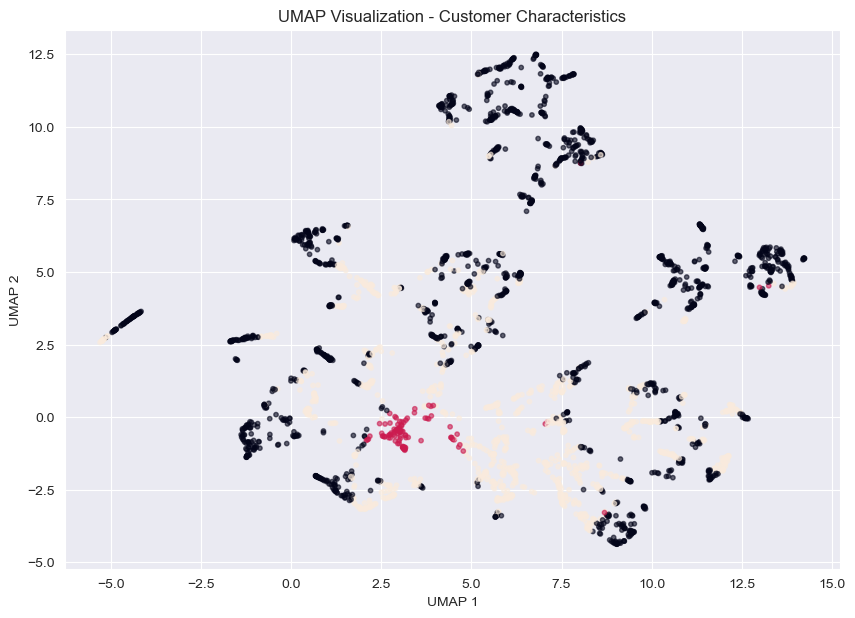

In [114]:
import umap
import matplotlib.pyplot as plt

# Use the same 3,000-customer sample used for t-SNE
umap_customer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_customer_umap = umap_customer.fit_transform(X_tsne_customer)

# Plot
plt.figure(figsize=(10, 7))

plt.scatter(
    X_customer_umap[:, 0],
    X_customer_umap[:, 1],
    c=y_tsne_customer,
    s=10,
    alpha=0.6
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization - Customer Characteristics")
plt.show()

### Observation

The UMAP visualization of the customer-characteristics representation reveals several compact local groups, indicating that some local structure exists within the customer data. However, the three K-Means clusters still show noticeable overlap, particularly around the central region of the visualization.

Although UMAP reveals more local structure than the PCA projection, it does not show three clearly separated global segments. This is consistent with the relatively low Silhouette Score of 0.1762, indicating that the customer-characteristics clusters have limited overall separation.

## Campaign

C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


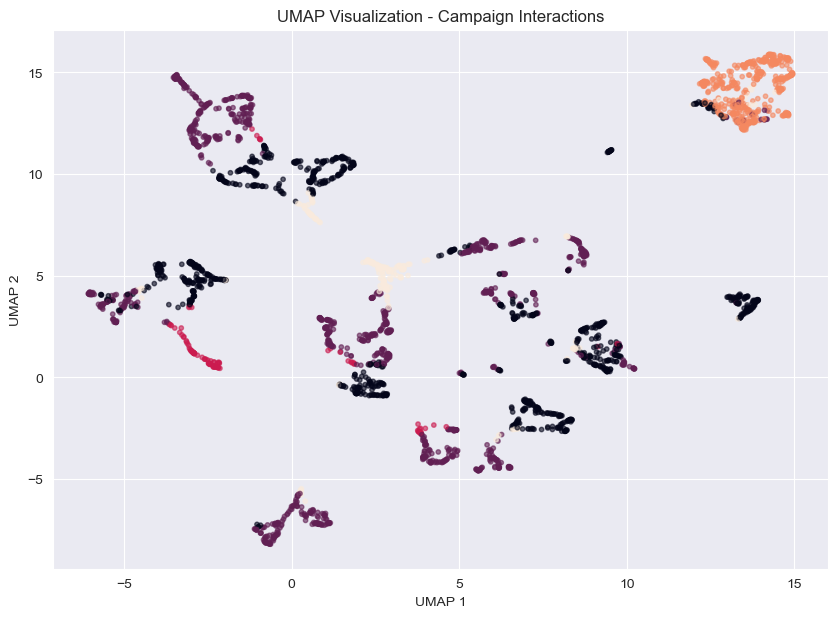

In [115]:
umap_campaign = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_campaign_umap = umap_campaign.fit_transform(X_tsne_campaign)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_campaign_umap[:, 0],
    X_campaign_umap[:, 1],
    c=y_tsne_campaign,
    s=10,
    alpha=0.6
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization - Campaign Interactions")
plt.show()

### Observation

The UMAP visualization of the campaign interaction representation shows clearer compact local groupings compared with the customer-characteristics representation. Several distinct regions can be observed, including a particularly concentrated group in the upper-right portion of the visualization.

Although some overlap between cluster labels remains, the campaign representation exhibits stronger visible structure overall. This is consistent with its higher Silhouette Score of 0.2103 compared with 0.1762 for the customer-characteristics representation.

| Dimensionality Reduction | Customer Characteristics                         | Campaign Interactions              |
| ------------------------ | ------------------------------------------------ | ---------------------------------- |
| **PCA**                  | Some structure, but substantial overlap          | Some structure, moderate overlap   |
| **t-SNE**                | Some local grouping, substantial overlap         | More visible local grouping        |
| **UMAP**                 | Several local groups, limited overall separation | Clearer and more compact groupings |
| **Overall**              | Weaker cluster structure                         | **Stronger cluster s**             |



# 19. Cluster Stability Analysis


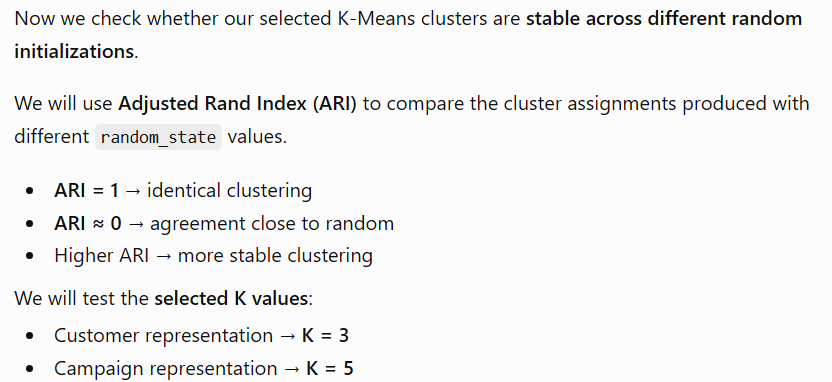

## Customer K-Means Stability

In [116]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import pandas as pd

seeds = [0, 10, 20, 30, 40]

customer_stability_labels = []

for seed in seeds:
    model = KMeans(
        n_clusters=3,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X_customer_processed)
    customer_stability_labels.append(labels)

# Compare every pair of runs
customer_stability_results = []

for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        ari = adjusted_rand_score(
            customer_stability_labels[i],
            customer_stability_labels[j]
        )

        customer_stability_results.append({
            "Seed 1": seeds[i],
            "Seed 2": seeds[j],
            "ARI": ari
        })

customer_stability_df = pd.DataFrame(customer_stability_results)

customer_stability_df

customer_mean_ari = customer_stability_df["ARI"].mean()

print("Mean Customer K-Means ARI:", customer_mean_ari)

Mean Customer K-Means ARI: 0.9997823781803371


### Observation

The Customer K-Means model achieved a mean Adjusted Rand Index (ARI) of 0.9998 across different random seeds. Since an ARI value close to 1 indicates very high agreement between clustering assignments, the result shows that the customer segmentation is highly stable across different initializations.

Therefore, the selected K=3 customer segmentation is highly consistent and reproducible.

## Campaign K mean Stability

In [117]:
# Campaign K-Means Stability

seeds = [0, 10, 20, 30, 40]

campaign_stability_labels = []

for seed in seeds:
    model = KMeans(
        n_clusters=5,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X_campaign_processed)
    campaign_stability_labels.append(labels)

campaign_stability_results = []

for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        ari = adjusted_rand_score(
            campaign_stability_labels[i],
            campaign_stability_labels[j]
        )

        campaign_stability_results.append({
            "Seed 1": seeds[i],
            "Seed 2": seeds[j],
            "ARI": ari
        })

campaign_stability_df = pd.DataFrame(campaign_stability_results)

campaign_stability_df

campaign_mean_ari = campaign_stability_df["ARI"].mean()

print("Mean Campaign K-Means ARI:", campaign_mean_ari)

Mean Campaign K-Means ARI: 0.9999030199085922


### Observation

The Campaign K-Means model achieved a mean Adjusted Rand Index (ARI) of 0.9999 across different random seeds. Since the ARI is extremely close to 1, the clustering assignments are highly consistent across different initializations.

Therefore, the selected K=5 campaign segmentation is highly stable and reproducible.


# 19. Post-Hoc Cluster Analysis Using y

## Subscription Rate by Customer Clusters

In [118]:
customer_y_analysis = df[["y"]].copy()
customer_y_analysis["cluster"] = cluster_labels

customer_subscription = pd.crosstab(
    customer_y_analysis["cluster"],
    customer_y_analysis["y"],
    normalize="index"
) * 100

customer_subscription

y,no,yes
cluster,,
0,88.428202,11.571798
1,85.118620,14.881380
2,88.362747,11.637253


In [119]:
customer_yes_rate = (
    customer_y_analysis
    .groupby("cluster")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index(name="subscription_rate")
)

customer_yes_rate

,cluster,subscription_rate
0,0,11.571798
1,1,14.881380
2,2,11.637253


### Observation

The post-hoc analysis shows that Cluster 1 has the highest term-deposit subscription rate at 14.88%. Clusters 0 and 2 have lower and very similar subscription rates of 11.57% and 11.64%, respectively.

Therefore, the customer-characteristics segmentation captures some differences in subscription behavior, although the differences between clusters are relatively small.

## Campaign Clusters and Subscription

In [120]:
campaign_y_analysis = df[["y"]].copy()
campaign_y_analysis["cluster"] = campaign_labels_final

campaign_yes_rate = (
    campaign_y_analysis
    .groupby("cluster")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index(name="subscription_rate")
)

campaign_yes_rate

,cluster,subscription_rate
0,0,7.184715
1,1,6.026232
2,2,3.021583
3,3,20.264379
4,4,47.295708


###  Observation

The post-hoc analysis shows substantial differences in subscription rates across the campaign-based clusters. Cluster 4 has the highest subscription rate at 47.30%, followed by Cluster 3 at 20.26%. Clusters 0, 1, and 2 have considerably lower subscription rates of 7.18%, 6.03%, and 3.02%, respectively.

This indicates that the campaign interaction representation captures stronger differences in subscription behavior than the customer-characteristics representation. In particular, Cluster 4 represents a group with a substantially higher observed subscription rate.

In [121]:
campaign_numeric_profile = (
    df_campaign_clusters
    .groupby("cluster")[campaign_numeric]
    .mean()
    .round(2)
)

campaign_numeric_profile

,day,duration,campaign,pdays,previous
cluster,,,,,
0,8.55,205.44,2.22,1.12,0.05
1,23.02,192.45,2.57,0.97,0.04
2,21.95,142.87,15.82,-0.49,0.02
3,14.13,237.51,2.09,245.31,3.39
4,15.88,929.26,2.43,11.44,0.18


###  Observation

The numerical profile shows that Cluster 4 is particularly distinct because its average call duration is 929.26 seconds, substantially higher than the other clusters. Cluster 3 is characterized by much higher values of `pdays` and `previous`, indicating greater previous campaign interaction. Cluster 2 has the highest average `campaign` value at 15.82, indicating repeated contact during the campaign.

The most notable characteristic of Cluster 4 is its exceptionally high average call duration, which coincides with its much higher observed subscription rate of 47.30%.

### Categorical Profile of Campaign Cluster 4

In [122]:
cluster4 = df_campaign_clusters[
    df_campaign_clusters["cluster"] == 4
    ]

for col in campaign_categorical:
    print(f"\n{col.upper()}")
    print(
        (cluster4[col].value_counts(normalize=True) * 100)
        .round(2)
    )


CONTACT
contact
cellular     66.08
unknown      28.63
telephone     5.29
Name: proportion, dtype: float64

MONTH
month
may    28.69
jul    19.43
aug    11.96
jun    11.17
nov    10.23
apr     7.85
feb     4.26
jan     2.50
oct     1.53
sep     1.29
mar     0.56
dec     0.53
Name: proportion, dtype: float64

POUTCOME
poutcome
unknown    92.27
failure     3.44
success     2.29
other       2.00
Name: proportion, dtype: float64


### Observation

Campaign Cluster 4 is primarily characterized by cellular contact (66.08%), while 28.63% of observations have an unknown contact method. The cluster is concentrated mainly in May (28.69%), July (19.43%), August (11.96%), June (11.17%), and November (10.23%).

The previous campaign outcome is predominantly unknown (92.27%), with relatively small proportions classified as failure (3.44%), success (2.29%), and other (2.00%).

Combined with its exceptionally high average call duration of 929.26 seconds and observed subscription rate of 47.30%, Cluster 4 represents the most notable high-subscription segment identified in the campaign-based analysis.

# Final Conclusion

# 21. Final Conclusion

The Bank Customer Segmentation project applied unsupervised learning techniques to identify naturally occurring groups of customers without using the target variable `y` during clustering.

Two feature representations were explored separately: customer characteristics and campaign interactions. Multiple clustering algorithms were experimented with, including K-Means, Agglomerative Clustering, DBSCAN, Spectral Clustering, and Gaussian Mixture Models. PCA, t-SNE, and UMAP were used to visualize the resulting cluster structures.

For the customer-characteristics representation, K-Means with K=3 achieved the highest Silhouette Score among the tested algorithms at 0.1762. The clustering was also highly stable, with a mean ARI of 0.9998 across different random initializations. However, the dimensionality-reduction visualizations showed substantial overlap, indicating relatively weak separation between customer segments.

For the campaign-interaction representation, K-Means with K=5 achieved the highest Silhouette Score at 0.2103 among the tested algorithms. The solution was highly stable, with a mean ARI of 0.9999. The t-SNE and UMAP visualizations also showed clearer local structure compared with the customer-characteristics representation.

Post-hoc analysis using the target variable `y` showed that the campaign-based clusters differed substantially in observed subscription rates. Cluster 4 had the highest subscription rate at 47.30%, while Cluster 2 had the lowest at 3.02%. Cluster 4 was particularly characterized by a very high average call duration of 929.26 seconds and predominantly cellular contact.

Overall, the experiments suggest that campaign interaction and previous campaign characteristics provide stronger segmentation structure and greater differences in observed subscription behavior than customer characteristics alone. The clustering results should be interpreted as descriptive segments rather than causal explanations, particularly because variables such as call duration are observed during the campaign.

The project demonstrates that unsupervised learning can reveal meaningful customer and campaign-interaction segments that can subsequently be analyzed for differences in banking outcomes.